In [104]:
import pandas as pd
import autoslo.utils.paths as pu
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df =pu.RunLocator.get_runs_df()

In [26]:
pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_s_options = [10, 30, 60, 120]
rpu_options = [4, 8, 16, 32]

results = []

for pct_heavy in pct_heavy_options:
    for mean_interarrival_s in mean_interarrival_s_options:
        for rpu in rpu_options:
            blueprint_name = f'single_{rpu}'
            workload_name = f'tpcds_99templates_{pct_heavy:02d}pctheavy_{mean_interarrival_s}meaninterarrivals'
            subset = df[
                (df['workload_name'] == workload_name) &
                (df['blueprint_name'] == blueprint_name)
            ]
            last_run_id = subset['run_id'].max()

            sys_query_history_df = pd.read_parquet(
                os.path.join(
                    pu.get_data_path(), 
                    'runs', 
                    str(last_run_id),
                    f'sys_query_history+cluster_{rpu}.parquet'
                )
            )

            results.append({
                'run_id': last_run_id,
                'pct_heavy_queries': pct_heavy,
                'mean_interarrival_s': mean_interarrival_s,
                'rpu': rpu,
                'num_queries': len(sys_query_history_df),
                'num_successful_queries': len(sys_query_history_df[sys_query_history_df['status'].str.startswith('success')]),
            })

In [28]:
results_df = pd.DataFrame(results)
results_df['success_rate'] = results_df['num_successful_queries'] / results_df['num_queries']
results_df = results_df.sort_values(['success_rate', 'num_queries'], ascending=False)
results_df

,run_id,pct_heavy_queries,mean_interarrival_s,rpu,num_queries,num_successful_queries,success_rate
2,1763253072,0,10,16,352,352,1.000000
3,1763928438,0,10,32,352,352,1.000000
18,1763270014,10,10,16,349,349,1.000000
19,1763945260,10,10,32,349,349,1.000000
34,1763286867,25,10,16,347,347,1.000000
...,...,...,...,...,...,...,...
49,1765440646,50,10,8,335,305,0.910448
32,1763306490,25,10,4,347,308,0.887608
56,1763329001,50,60,4,54,41,0.759259
48,1763346358,50,10,4,335,242,0.722388


In [99]:
from autoslo.workload_execution.trace import Trace
from autoslo.featurization.iconq_query_featurizer import IconqQueryFeaturizer

featurizer = IconqQueryFeaturizer.load('1767983773')


# Collect all the data of isolated queries from each run.
sub_dfs = []
for _, row in results_df.iterrows():
    trace = Trace(row['run_id'])
    sys_query_history_df = trace._dfs['sys_query_history'][f'cluster_{row["rpu"]}']
    sys_query_history_df = sys_query_history_df.copy()
    sys_query_history_df['run_id'] = row['run_id']

    # Add additional info from other trace attributes.
    num_external_tables = trace.num_external_tables()
    num_system_tables = trace.num_system_tables()
    num_permanent_tables = trace.num_permanent_tables()

    num_joins = trace.num_joins()
    num_scans = trace.num_scans()
    num_aggregates = trace.num_aggregates()

    sys_query_history_df['num_joins'] = sys_query_history_df['query_id'].map(num_joins)
    sys_query_history_df['num_scans'] = sys_query_history_df['query_id'].map(num_scans)
    sys_query_history_df['num_aggregates'] = sys_query_history_df['query_id'].map(num_aggregates)

    sys_query_history_df['num_permanent_tables'] = sys_query_history_df['query_id'].map(num_permanent_tables)
    sys_query_history_df['num_system_tables'] = sys_query_history_df['query_id'].map(num_system_tables)
    sys_query_history_df['num_external_tables'] = sys_query_history_df['query_id'].map(num_external_tables)

    # Find queries that do not overlap with others.
    start_times = trace.arrival_times()
    end_times = trace.completion_times()
    non_overlapping_queries = []
    events = []
    for query_id in start_times.index:
        events.append((start_times[query_id], '1_start', query_id))
        events.append((end_times[query_id], '2_end', query_id))

    events.sort()

    running_queries = set()
    saw_a_query_overlap = {}
    for timestamp, event_type, query_id in events:
        if event_type == '1_start':
            if len(running_queries) > 0:
                saw_a_query_overlap[query_id] = True
                for rq in running_queries:
                    saw_a_query_overlap[rq] = True
            running_queries.add(query_id)
        elif event_type == '2_end':
            running_queries.remove(query_id)

    non_overlapping_query_ids = [qid for qid in start_times.index if qid not in saw_a_query_overlap]

    # Further filter to successful queries only.
    non_overlapping_successful_query_ids = sys_query_history_df[
        (sys_query_history_df['status'].str.startswith('success')) &
        (sys_query_history_df['query_id'].isin(non_overlapping_query_ids))
    ]['query_id'].tolist()

    # Compute featurizations.
    temp_and_q_idxs = trace.tpcds_temp_and_q_idxs
    sys_query_history_df['tpcds_temp_and_q_idxs'] = sys_query_history_df['query_id'].map(temp_and_q_idxs)
    sys_query_history_df['featurization'] = sys_query_history_df['tpcds_temp_and_q_idxs'].map(featurizer.featurize_from_tpcds_temp_and_q_idx)

        
    # For each query, look at the most recently completed prior query at the time of its arrival
    # and collect its query_id
    sys_query_history_df['most_recent_completed_query_id'] = None
    events = []
    for query_id in start_times.index:
        events.append((start_times[query_id], '1_start', query_id))
        events.append((end_times[query_id], '2_end', query_id))

    events.sort()

    running_queries = set()
    completed_queries = []
    for timestamp, event_type, query_id in events:
        if event_type == '1_start':
            if len(completed_queries) > 0:
                most_recent_completed_query_id = completed_queries[-1]
                sys_query_history_df.loc[sys_query_history_df['query_id'] == query_id, 'most_recent_completed_query_id'] = most_recent_completed_query_id
            running_queries.add(query_id)
        elif event_type == '2_end':
            running_queries.remove(query_id)
            completed_queries.append(query_id)

    # Get the cosine similarity of a query's table accesses to that of its most recently completed prior query
    sys_query_history_df['most_recent_completed_featurization'] = sys_query_history_df['most_recent_completed_query_id'].map(sys_query_history_df.set_index('query_id')['featurization'])
    sys_query_history_df['most_recent_table_sim'] = sys_query_history_df.apply(
        lambda row:
        featurizer.table_access_pattern_cosine_similarity(
            row['featurization'],
            row['most_recent_completed_featurization']
        ) if type(row['most_recent_completed_featurization']) is not float else 0.0,
        axis=1
    )

    # Keep only non-overlapping successful queries and add them to rows.
    sub_dfs.append(
        sys_query_history_df[
            sys_query_history_df['query_id'].isin(non_overlapping_successful_query_ids)
        ]
    )
overall_df = pd.concat(sub_dfs, ignore_index=True)
    

In [102]:
overall_df.shape

(2636, 19)

In [122]:
def plot_scatter(train_y_true, train_y_pred, val_y_true, val_y_pred, test_y_true, test_y_pred):

    plt.scatter(train_y_true, train_y_pred, color="blue")
    plt.scatter(val_y_true, val_y_pred, color="green")
    plt.scatter(test_y_true, test_y_pred, color="red")
    # Plot a line through diagonal
    min_y = min(
        min(train_y_true), min(test_y_true), min(train_y_pred), min(test_y_pred),
        min(val_y_true), min(val_y_pred)
    )
    max_y = max(
        max(train_y_true), max(test_y_true), max(train_y_pred), max(test_y_pred),
        max(val_y_true), max(val_y_pred)
    )
    plt.plot([min_y, max_y], [min_y, max_y], "r--")

    # Add a text annotation with mean, p50, p90, p95 Q-error for each of train and test
    for dataset, y_true, y_pred, color in [
        ("Train", train_y_true, train_y_pred, "blue"),
        ("Test", test_y_true, test_y_pred, "red"),
        ("Validation", val_y_true, val_y_pred, "green"),
    ]:
        q_errors = np.maximum(y_pred / y_true, y_true / y_pred)
        mean_q_error = q_errors.mean()
        p50_q_error = np.quantile(q_errors, 0.5)
        p90_q_error = np.quantile(q_errors, 0.9)
        p95_q_error = np.quantile(q_errors, 0.95)

        # Add the text annotation to the right of the plot area, top for train,middle for val,bottom for test
        ypos = max_y if dataset == "Train" else min_y if dataset == "Test" else np.exp(np.mean([np.log(max_y), np.log(min_y)]))
        va = "top" if dataset == "Train" else "bottom" if dataset == "Test" else "center"
        plt.text(
            max_y * 1.1,
            ypos,
            f"{dataset}:\nMean Q-error: {mean_q_error:.2f}\nP50 Q-error: {p50_q_error:.2f}\nP90 Q-error: {p90_q_error:.2f}\nP95 Q-error: {p95_q_error:.2f}",
            verticalalignment=va,
            color=color,
        )
    plt.xlabel("True Elapsed Time")
    plt.ylabel("Predicted Elapsed Time")
    plt.title(
        "True vs Predicted Elapsed Time using XGBoost with Query Featurizations"
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.show()

In [108]:
overall_df

,query_id,start_time,end_time,elapsed_time,status,result_cache_hit,query_type,run_id,num_joins,num_scans,num_aggregates,num_permanent_tables,num_system_tables,num_external_tables,tpcds_temp_and_q_idxs,featurization,most_recent_completed_query_id,most_recent_completed_featurization,most_recent_table_sim
0,cluster_16_10969733#fc577c06-42cf-44d6-8e66-8b...,2025-11-16 00:44:42.943489,2025-11-16 00:44:44.397112,1453623,success,False,SELECT,1763253072,6,11,3,6,0,0,001_001,"[8.0, 23.262456591536385, 6.0, 15.590764558292...",cluster_16_10969580#fc577c06-42cf-44d6-8e66-8b...,"[6.0, 21.584561326672095, 0.0, 0.0, 0.0, 0.0, ...",0.000000
1,cluster_16_10969753#fc577c06-42cf-44d6-8e66-8b...,2025-11-16 00:44:57.817723,2025-11-16 00:45:05.545367,7727644,success,False,SELECT,1763253072,2,3,1,3,0,0,003_001,"[3.0, 24.919289804565842, 2.0, 10.950666186264...",cluster_16_10969733#fc577c06-42cf-44d6-8e66-8b...,"[8.0, 23.262456591536385, 6.0, 15.590764558292...",0.094299
2,cluster_16_10969762#fc577c06-42cf-44d6-8e66-8b...,2025-11-16 00:45:15.536870,2025-11-16 00:45:16.788429,1251559,success,False,SELECT,1763253072,7,10,2,8,0,0,039_003,"[8.0, 23.944474999224347, 7.0, 14.703214143390...",cluster_16_10969753#fc577c06-42cf-44d6-8e66-8b...,"[3.0, 24.919289804565842, 2.0, 10.950666186264...",0.244958
3,cluster_16_10969774#fc577c06-42cf-44d6-8e66-8b...,2025-11-16 00:45:28.575890,2025-11-16 00:45:28.907535,331645,success,False,SELECT,1763253072,4,5,1,5,0,0,040_001,"[5.0, 24.74632354121972, 4.0, 19.0886077322763...",cluster_16_10969762#fc577c06-42cf-44d6-8e66-8b...,"[8.0, 23.944474999224347, 7.0, 14.703214143390...",0.222810
4,cluster_16_10969783#fc577c06-42cf-44d6-8e66-8b...,2025-11-16 00:45:43.743386,2025-11-16 00:45:54.206513,10463127,success,False,SELECT,1763253072,3,7,2,4,0,0,051_001,"[4.0, 25.150524739882517, 3.0, 21.999442078493...",cluster_16_10969774#fc577c06-42cf-44d6-8e66-8b...,"[5.0, 24.74632354121972, 4.0, 19.0886077322763...",0.041561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2631,cluster_32_8737477#17081f06-fbfa-451a-85a9-81b...,2025-11-24 07:27:09.130140,2025-11-24 07:27:09.302620,172480,success,False,SELECT,1763966257,2,3,1,3,0,0,042_003,"[3.0, 24.919289641501678, 2.0, 10.739890564942...",cluster_32_8737349#17081f06-fbfa-451a-85a9-81b...,"[9.0, 25.028863368340133, 8.0, 16.846287529553...",0.928691
2632,cluster_32_8737526#17081f06-fbfa-451a-85a9-81b...,2025-11-24 07:28:18.691878,2025-11-24 07:28:19.114217,422339,success,False,SELECT,1763966257,2,3,1,3,0,0,086_002,"[3.0, 23.573232787130394, 2.0, 15.789768790507...",cluster_32_8737477#17081f06-fbfa-451a-85a9-81b...,"[3.0, 24.919289641501678, 2.0, 10.739890564942...",0.259455
2633,cluster_32_8737611#17081f06-fbfa-451a-85a9-81b...,2025-11-24 07:30:00.200665,2025-11-24 07:30:08.446736,8246071,success,False,SELECT,1763966257,11,24,8,12,0,0,074_003,"[12.0, 25.822264874354822, 11.0, 21.7576088119...",cluster_32_8737526#17081f06-fbfa-451a-85a9-81b...,"[3.0, 23.573232787130394, 2.0, 15.789768790507...",0.516159
2634,cluster_32_8737754#17081f06-fbfa-451a-85a9-81b...,2025-11-24 07:33:12.892417,2025-11-24 07:33:13.064321,171904,success,False,SELECT,1763966257,2,3,1,3,0,0,042_001,"[3.0, 24.919289640417695, 2.0, 10.738329589015...",cluster_32_8737611#17081f06-fbfa-451a-85a9-81b...,"[12.0, 25.822264874354822, 11.0, 21.7576088119...",0.587953


In [109]:
# Assign rows to train, val, test
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(overall_df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

[0]	train-rmse:1.38680	validation-rmse:1.40918
[1]	train-rmse:1.31823	validation-rmse:1.33937
[2]	train-rmse:1.27775	validation-rmse:1.29728
[3]	train-rmse:1.25366	validation-rmse:1.27644
[4]	train-rmse:1.24066	validation-rmse:1.26288
[5]	train-rmse:1.22589	validation-rmse:1.25245
[6]	train-rmse:1.21635	validation-rmse:1.24451
[7]	train-rmse:1.21170	validation-rmse:1.24153
[8]	train-rmse:1.20989	validation-rmse:1.23986
[9]	train-rmse:1.20718	validation-rmse:1.24037
[10]	train-rmse:1.20604	validation-rmse:1.23976
[11]	train-rmse:1.20368	validation-rmse:1.23847
[12]	train-rmse:1.20328	validation-rmse:1.23906
[13]	train-rmse:1.20220	validation-rmse:1.23853
[14]	train-rmse:1.20159	validation-rmse:1.23872
[15]	train-rmse:1.20127	validation-rmse:1.23884
[16]	train-rmse:1.20112	validation-rmse:1.23882
[17]	train-rmse:1.20106	validation-rmse:1.23871
[18]	train-rmse:1.20100	validation-rmse:1.23878
[19]	train-rmse:1.20095	validation-rmse:1.23880
[20]	train-rmse:1.20085	validation-rmse:1.23920


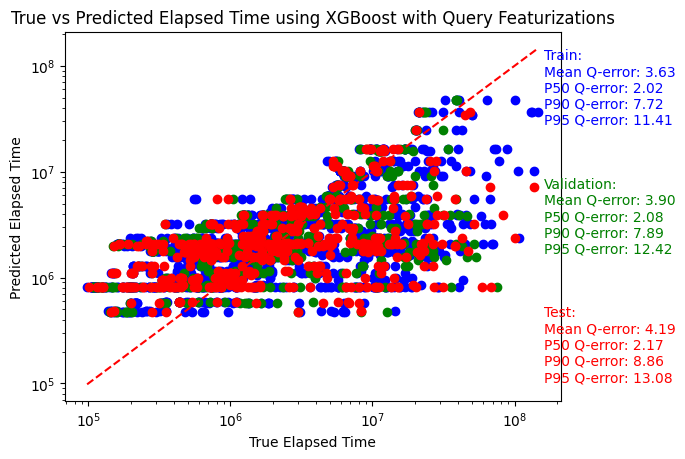

In [127]:
# Try with xgboost and basic features

import xgboost as xgb
train_x = train_df[['num_joins', 'num_scans', 'num_aggregates', 'num_permanent_tables', 'num_system_tables', 'num_external_tables']]
train_y = np.log1p(train_df['elapsed_time'])
dtrain = xgb.DMatrix(train_x, label=train_y)

val_x = val_df[['num_joins', 'num_scans', 'num_aggregates', 'num_permanent_tables', 'num_system_tables', 'num_external_tables']]
val_y = np.log1p(val_df['elapsed_time'])
dval = xgb.DMatrix(val_x, label=val_y)

test_x = test_df[['num_joins', 'num_scans', 'num_aggregates', 'num_permanent_tables', 'num_system_tables', 'num_external_tables']]
test_y = np.log1p(test_df['elapsed_time'])
dtest = xgb.DMatrix(test_x, label=test_y)

params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
bst = xgb.train(params, dtrain, num_boost_round=100, evals=[(dtrain, 'train'), (dval, 'validation')], early_stopping_rounds=10)

train_y_pred = np.expm1(bst.predict(dtrain))
val_y_pred = np.expm1(bst.predict(dval))
test_y_pred = np.expm1(bst.predict(dtest))

plot_scatter(
    np.expm1(train_y), train_y_pred,
    np.expm1(val_y), val_y_pred,
    np.expm1(test_y), test_y_pred
)

[0]	train-rmse:1.32384	validation-rmse:1.35013
[1]	train-rmse:1.22219	validation-rmse:1.24984
[2]	train-rmse:1.16637	validation-rmse:1.19210
[3]	train-rmse:1.13578	validation-rmse:1.16085
[4]	train-rmse:1.11746	validation-rmse:1.14437
[5]	train-rmse:1.10072	validation-rmse:1.13278
[6]	train-rmse:1.09275	validation-rmse:1.12514
[7]	train-rmse:1.08556	validation-rmse:1.12288
[8]	train-rmse:1.08274	validation-rmse:1.12174
[9]	train-rmse:1.08006	validation-rmse:1.11827
[10]	train-rmse:1.07829	validation-rmse:1.11746
[11]	train-rmse:1.07665	validation-rmse:1.11628
[12]	train-rmse:1.07607	validation-rmse:1.11587
[13]	train-rmse:1.07533	validation-rmse:1.11574
[14]	train-rmse:1.07509	validation-rmse:1.11597
[15]	train-rmse:1.07441	validation-rmse:1.11461
[16]	train-rmse:1.07429	validation-rmse:1.11432
[17]	train-rmse:1.07397	validation-rmse:1.11410
[18]	train-rmse:1.07386	validation-rmse:1.11398
[19]	train-rmse:1.07369	validation-rmse:1.11426
[20]	train-rmse:1.07349	validation-rmse:1.11385
[2

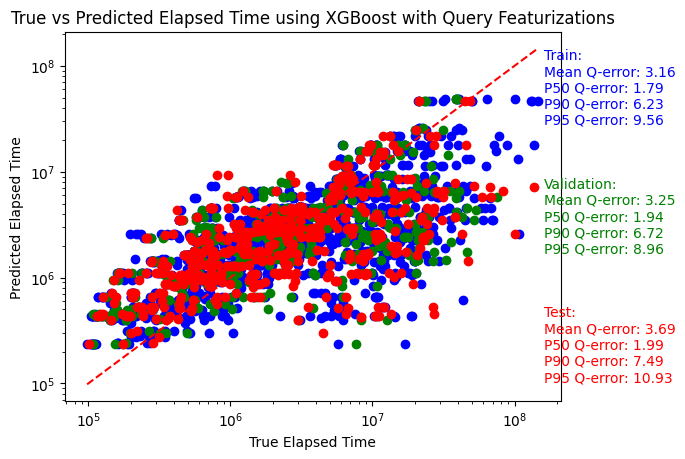

In [128]:
# Now train again buut with featurizations
train_x = np.vstack(train_df['featurization'].to_numpy())
train_y = np.log1p(train_df['elapsed_time'])
dtrain = xgb.DMatrix(train_x, label=train_y)

val_x = np.vstack(val_df['featurization'].to_numpy())
val_y = np.log1p(val_df['elapsed_time'])
dval = xgb.DMatrix(val_x, label=val_y)

test_x = np.vstack(test_df['featurization'].to_numpy())
test_y = np.log1p(test_df['elapsed_time'])
dtest = xgb.DMatrix(test_x, label=test_y)

params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
bst = xgb.train(params, dtrain, num_boost_round=100, evals=[(dtrain, 'train'), (dval, 'validation')], early_stopping_rounds=10)

train_y_pred = np.expm1(bst.predict(dtrain))
val_y_pred = np.expm1(bst.predict(dval))
test_y_pred = np.expm1(bst.predict(dtest))

plot_scatter(
    np.expm1(train_y), train_y_pred,
    np.expm1(val_y), val_y_pred,
    np.expm1(test_y), test_y_pred
)

[0]	train-rmse:1.31449	validation-rmse:1.35203
[1]	train-rmse:1.21078	validation-rmse:1.25372
[2]	train-rmse:1.14220	validation-rmse:1.18622
[3]	train-rmse:1.09676	validation-rmse:1.15241
[4]	train-rmse:1.05692	validation-rmse:1.12642
[5]	train-rmse:1.02230	validation-rmse:1.10921
[6]	train-rmse:1.00399	validation-rmse:1.09795
[7]	train-rmse:0.98835	validation-rmse:1.08999
[8]	train-rmse:0.97791	validation-rmse:1.08814
[9]	train-rmse:0.96447	validation-rmse:1.07970
[10]	train-rmse:0.95139	validation-rmse:1.07308
[11]	train-rmse:0.94004	validation-rmse:1.06748
[12]	train-rmse:0.93141	validation-rmse:1.06694
[13]	train-rmse:0.92527	validation-rmse:1.06716
[14]	train-rmse:0.91931	validation-rmse:1.06400
[15]	train-rmse:0.91391	validation-rmse:1.06034
[16]	train-rmse:0.90827	validation-rmse:1.05742
[17]	train-rmse:0.90391	validation-rmse:1.05760
[18]	train-rmse:0.90124	validation-rmse:1.05952
[19]	train-rmse:0.89852	validation-rmse:1.05941
[20]	train-rmse:0.89541	validation-rmse:1.05814
[2

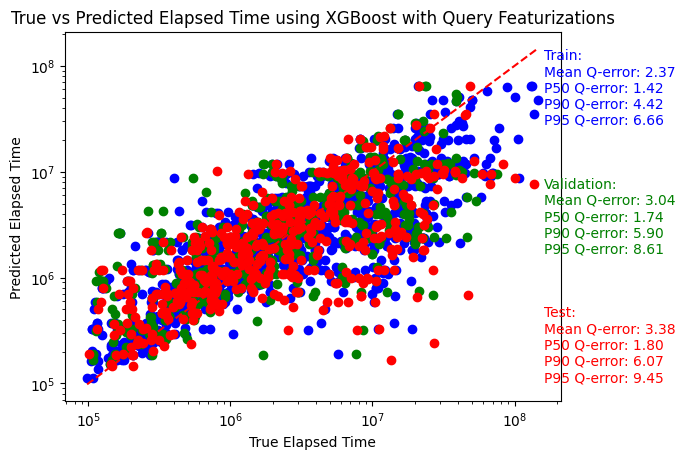

In [129]:
# Now also use most_recent_table_sim as a feature
train_x = np.hstack([
    np.vstack(train_df['featurization'].to_numpy()),
    train_df[['most_recent_table_sim']].to_numpy()
])
train_y = np.log1p(train_df['elapsed_time'])    
dtrain = xgb.DMatrix(train_x, label=train_y)

val_x = np.hstack([
    np.vstack(val_df['featurization'].to_numpy()),
    val_df[['most_recent_table_sim']].to_numpy()
])
val_y = np.log1p(val_df['elapsed_time'])
dval = xgb.DMatrix(val_x, label=val_y)

test_x = np.hstack([
    np.vstack(test_df['featurization'].to_numpy()),
    test_df[['most_recent_table_sim']].to_numpy()
])
test_y = np.log1p(test_df['elapsed_time'])
dtest = xgb.DMatrix(test_x, label=test_y)

params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
bst = xgb.train(params, dtrain, num_boost_round=100, evals=[(dtrain, 'train'), (dval, 'validation')], early_stopping_rounds=10)

train_y_pred = np.expm1(bst.predict(dtrain))
val_y_pred = np.expm1(bst.predict(dval))
test_y_pred = np.expm1(bst.predict(dtest))

plot_scatter(
    np.expm1(train_y), train_y_pred,
    np.expm1(val_y), val_y_pred,
    np.expm1(test_y), test_y_pred
)